# Project: AI for Fraud Detection

**Introduction**

Financial fraud is a major challenge in today’s digital economy, leading to significant losses for businesses and individuals. With the rapid growth of online transactions, detecting fraudulent activities in real-time has become increasingly important.

This project focuses on building a machine learning model to identify fraudulent credit card transactions. Using historical transaction data, the model learns patterns associated with fraud and distinguishes them from legitimate transactions.

The solution leverages data analysis and machine learning techniques to improve fraud detection accuracy and support smarter decision-making in financial systems.


**Objective**

The main objective of this project is to develop a machine learning model capable of detecting fraudulent transactions with high accuracy.

Specific goals include:
- To analyze transaction data and understand patterns associated with fraud
- To handle class imbalance in the dataset effectively
- To build and train a classification model for fraud detection
- To evaluate model performance using appropriate metrics such as precision, recall, and F1-score
- To provide insights that can help reduce financial fraud risks


**Expected Outcome**

At the end of this project, the following outcomes are expected:

- A well-analyzed dataset with clear insights into fraudulent and non-fraudulent transactions
- A trained machine learning model capable of predicting fraudulent activities
- Performance evaluation of the model using key classification metrics
- Visualizations that highlight transaction patterns and fraud distribution
- A scalable approach that can be applied to real-world fraud detection systems

## Data Loading and Inspection

In this step, the dataset is loaded using the pandas library. Initial exploration is performed to understand the structure of the dataset, including the number of rows and columns, data types, and summary statistics.

- `head()` displays the first few rows of the dataset
- `info()` provides details about data types and missing values
- `describe()` summarizes numerical features

This step ensures that the dataset is properly loaded and ready for analysis.

In [ ]:
import pandas as pd

df = pd.read_csv("creditcard.csv")

df.head()
df.info()
df['Class'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,count
Class,
0,284315
1,492


### Insight from Data Inspection

The dataset contains 284,807 transactions with 31 features, including the target variable `Class`.

- All features are numerical, indicating that the dataset has already been preprocessed and anonymized.
- There are no missing values, which simplifies data preparation.

From the class distribution:
- The majority of transactions are non-fraudulent (`Class = 0`)
- A very small percentage represents fraudulent transactions (`Class = 1`)

This confirms that the dataset is highly imbalanced, which is a common challenge in fraud detection problems and must be addressed during model training.

### EXPLORATORY DATA ANALYSIS

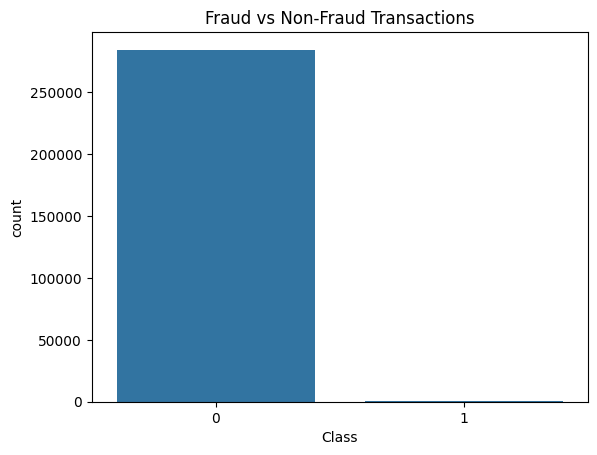

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Class', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

**Class Distribution Visualization**

The count plot above clearly shows a significant imbalance between fraudulent and non-fraudulent transactions.

- Non-fraudulent transactions dominate the dataset
- Fraudulent transactions are extremely rare

This imbalance is critical because a model could achieve high accuracy by simply predicting all transactions as non-fraud. Therefore, evaluation metrics such as precision, recall, and F1-score will be more appropriate than accuracy alone.

**Transaction Amount Analysis**

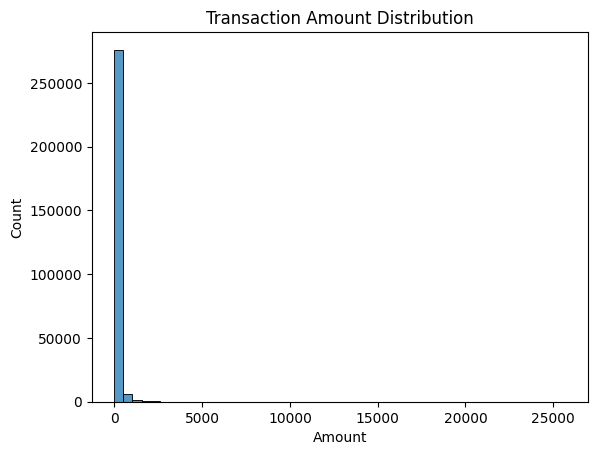

In [ ]:
sns.histplot(df['Amount'], bins=50)
plt.title("Transaction Amount Distribution")
plt.show()

The distribution of transaction amounts shows that most transactions are of low value, with a few high-value outliers.

This indicates that fraudulent transactions may not necessarily be associated with high transaction amounts alone, making detection more complex.

**Fraud vs Normal Comparison**

In [ ]:
fraud = df[df['Class'] == 1]
normal = df[df['Class'] == 0]

print("Fraud Transactions Summary:")
print(fraud['Amount'].describe())

print("\nNormal Transactions Summary:")
print(normal['Amount'].describe())

Fraud Transactions Summary:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Normal Transactions Summary:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


To better understand transaction behavior, the dataset was divided into fraudulent and non-fraudulent transactions.

The comparison shows that:
- Fraudulent transactions are not always high-value
- There is overlap in transaction amounts between both classes

This indicates that fraud detection requires more than simple rules and must rely on patterns across multiple features.

**Transaction Amount vs Class**

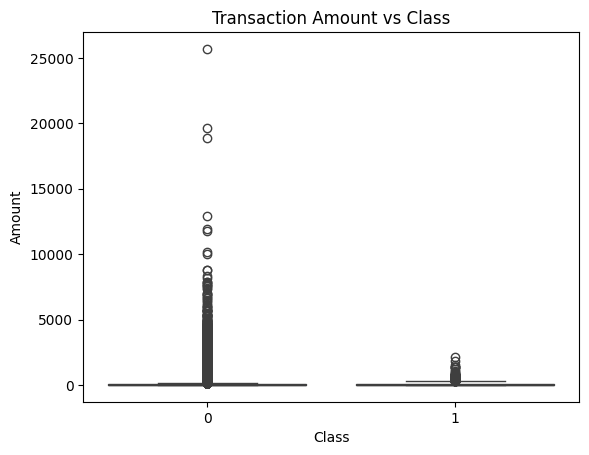

In [ ]:
sns.boxplot(x='Class', y='Amount', data=df)
plt.title("Transaction Amount vs Class")
plt.show()

The boxplot illustrates the distribution of transaction amounts for both fraudulent and non-fraudulent transactions.

- There is significant overlap between both classes
- Outliers are present in both categories

This further confirms that fraudulent behavior cannot be identified using a single variable and requires machine learning models for accurate detection.

**Feature Correlation Matrix**

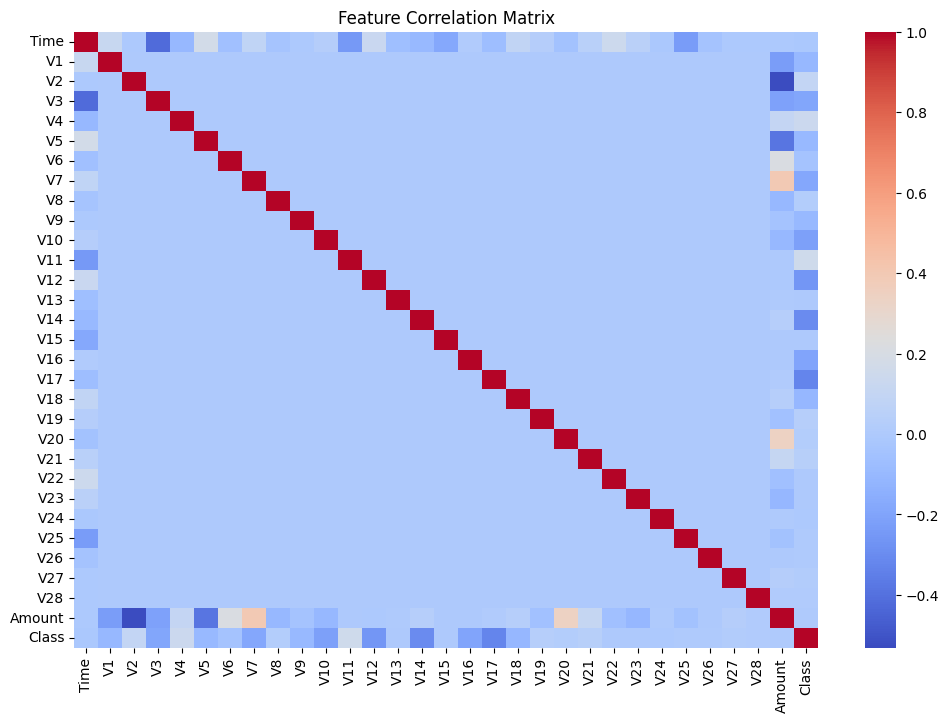

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

**Correlation Analysis**

The correlation matrix highlights relationships between features and the target variable.

- Most features show weak correlations, indicating that fraud detection is not dependent on a single variable
- A few features exhibit stronger relationships with the target, suggesting their importance in identifying fraudulent patterns

This reinforces the need for machine learning models that can capture complex, multi-dimensional relationships within the data.

### Data Preprocessing + Model Building




Before training the model, the dataset is prepared by separating features and the target variable.

Due to class imbalance, appropriate techniques will be considered during model training to ensure fair learning.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training set shape: (227845, 30)
Test set shape: (56962, 30)


The dataset is divided into features (X) and the target variable (y), where:

- X contains all transaction features
- y represents whether a transaction is fraudulent or not

The data is split into training and testing sets using an 80/20 ratio. Stratified sampling is used to preserve the original class distribution, which is important due to the imbalanced nature of the dataset.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Feature scaling was applied using StandardScaler to normalize the data.

This is important for Logistic Regression because:
- It improves model convergence
- It ensures all features contribute equally
- It prevents features with large values from dominating the model

**Handling Class Imbalance**

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='liblinear'
)

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear')

Since fraudulent transactions are rare, the dataset is highly imbalanced.

To address this, the model is trained using the `class_weight='balanced'` parameter. This ensures that the model gives more importance to the minority class (fraud cases), improving its ability to detect fraudulent transactions.

### Model Training

A Logistic Regression model was used as a baseline classifier for fraud detection.

This model is suitable because:
- It performs well for binary classification problems
- It is computationally efficient
- It provides interpretable results

It serves as a strong baseline before exploring more advanced models.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

Confusion Matrix:

[[55479  1385]
 [    8    90]]


**Model Performance Interpretation**

The model demonstrates strong performance in detecting fraudulent transactions, with a recall score of 0.92 for the fraud class. This means that 92% of actual fraud cases were correctly identified.

However, the precision for fraud detection is low (0.06), indicating that many non-fraudulent transactions were incorrectly flagged as fraud.

This trade-off highlights a key challenge in fraud detection systems:
- High recall ensures that most fraud cases are caught
- Low precision leads to more false alarms

In real-world applications, this trade-off is often acceptable because missing a fraudulent transaction can result in significant financial loss. Therefore, prioritizing recall is a strategic decision in fraud detection. Although the model achieved high accuracy, this metric is not reliable due to class imbalance. Therefore, precision and recall provide a more meaningful evaluation.

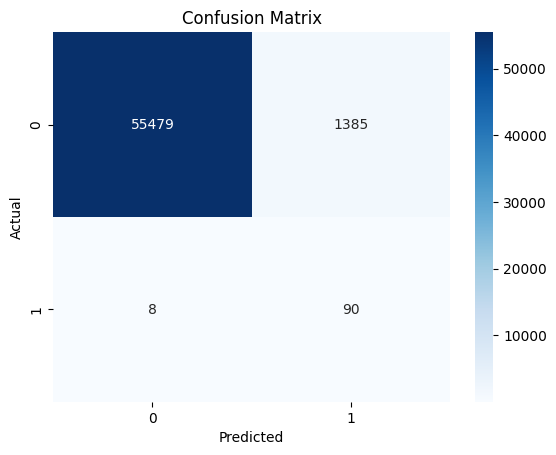

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**Confusion Matrix Interpretation**

The confusion matrix shows:

- True Positives (90): Fraud cases correctly detected
- True Negatives (55,479): Normal transactions correctly classified
- False Positives (1,385): Normal transactions incorrectly flagged as fraud
- False Negatives (8): Fraud cases missed

Minimizing false negatives is critical in fraud detection, and the model performs well in this regard by detecting most fraudulent transactions.

**Limitations**

- The dataset is highly imbalanced, which affects precision
- The model produces a high number of false positives
- Logistic Regression may not capture complex non-linear relationships in the data

These limitations highlight the need for more advanced models and techniques.

**Future Improvements**

- Use advanced models such as Random Forest or XGBoost for better performance
- Apply resampling techniques like SMOTE to improve class balance
- Perform hyperparameter tuning to optimize model results
- Deploy the model using a web application (e.g., Streamlit)
- Implement real-time fraud detection systems

## Final Conclusion

This project successfully demonstrated the application of machine learning in detecting fraudulent financial transactions.

Through exploratory data analysis, key patterns such as class imbalance and transaction behavior were identified. A Logistic Regression model with class balancing was implemented and evaluated using appropriate metrics.

The model achieved high recall in detecting fraudulent transactions, making it effective in minimizing missed fraud cases, which is critical in real-world financial systems.

Overall, this project demonstrates how machine learning can be applied to detect fraud and improve financial security.

In [ ]:
import joblib

In [ ]:
joblib.dump(model, "model.pkl")

['model.pkl']

In [ ]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']